In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import download_prices
from src.returns import compute_simple_returns
from src.pairs import compute_return_correlations, get_unique_pairs, rank_pairs_by_correlation

In [3]:
from src.data import download_prices

tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

prices = download_prices(
    tickers=tickers,
    start="2015-01-01",
    end="2026-01-01",
)

returns = compute_simple_returns(prices)

ranked_pairs = rank_pairs_by_correlation(returns)

print(prices.shape)
print(returns.shape)
print(ranked_pairs.shape)
print(ranked_pairs.head(10))

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
(2766, 15)
(2765, 15)
(105, 3)
   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
3       SPY      XLF     0.846784


In [4]:
high_corr_pairs = ranked_pairs[ranked_pairs["correlation"] >= 0.85]

print(high_corr_pairs)
print(high_corr_pairs.shape)

   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
(9, 3)


In [5]:
print(prices.shape)
print(returns.shape)
print(ranked_pairs.shape)
print(ranked_pairs.head(10))

(2766, 15)
(2765, 15)
(105, 3)
   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
3       SPY      XLF     0.846784


In [6]:
ticker_y = "XLK"
ticker_x = "QQQ"

In [7]:
from src.spread import estimate_hedge_ratio, compute_spread

alpha, beta = estimate_hedge_ratio(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
)

spread = compute_spread(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    alpha=alpha,
    beta=beta,
)

print("alpha:", alpha)
print("beta:", beta)
print(spread.head())
print(spread.describe())

alpha: -6.083477534786367
beta: 0.24068529955583914
Date
2015-01-02    1.386741
2015-01-05    1.444847
2015-01-06    1.531087
2015-01-07    1.394679
2015-01-08    1.355285
Name: XLK_QQQ_spread, dtype: float64
count    2.766000e+03
mean    -4.282780e-14
std      2.489940e+00
min     -6.904320e+00
25%     -1.007093e+00
50%      2.242802e-01
75%      1.381208e+00
max      5.553757e+00
Name: XLK_QQQ_spread, dtype: float64


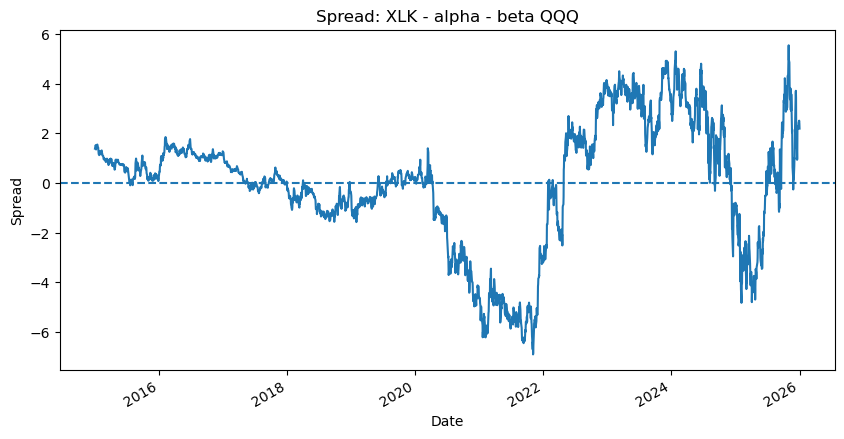

In [8]:
import matplotlib.pyplot as plt

ax = spread.plot(figsize=(10, 5))

ax.axhline(spread.mean(), linestyle="--")
ax.set_title(f"Spread: {ticker_y} - alpha - beta {ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
plt.show()

In [9]:
print("alpha:", alpha)
print("beta:", beta)
print(spread.describe())

alpha: -6.083477534786367
beta: 0.24068529955583914
count    2.766000e+03
mean    -4.282780e-14
std      2.489940e+00
min     -6.904320e+00
25%     -1.007093e+00
50%      2.242802e-01
75%      1.381208e+00
max      5.553757e+00
Name: XLK_QQQ_spread, dtype: float64


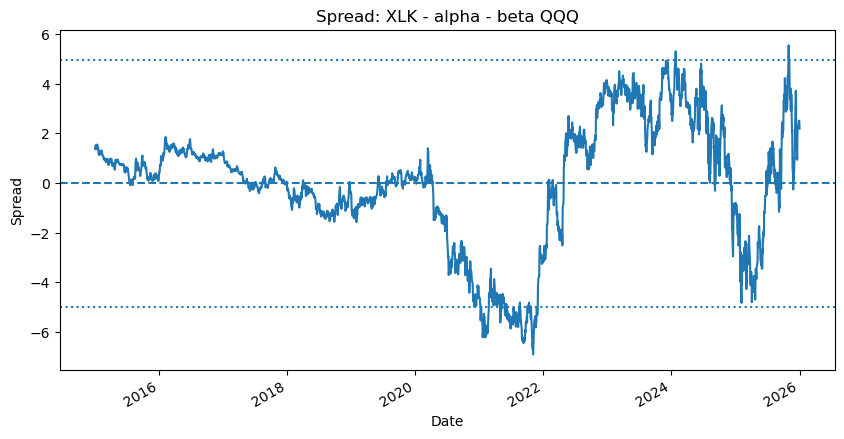

In [10]:
ax = spread.plot(figsize=(10, 5))

ax.axhline(spread.mean(), linestyle="--")
ax.axhline(spread.mean() + 2 * spread.std(), linestyle=":")
ax.axhline(spread.mean() - 2 * spread.std(), linestyle=":")

ax.set_title(f"Spread: {ticker_y} - alpha - beta {ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
plt.show()

In [11]:
from src.spread import compute_zscore

In [13]:
zscore = compute_zscore(spread)
print(zscore.head())
print(zscore.describe())

Date
2015-01-02    0.556938
2015-01-05    0.580274
2015-01-06    0.614909
2015-01-07    0.560126
2015-01-08    0.544304
Name: XLK_QQQ_spread_zscore, dtype: float64
count    2.766000e+03
mean    -5.137692e-17
std      1.000000e+00
min     -2.772886e+00
25%     -4.044649e-01
50%      9.007456e-02
75%      5.547155e-01
max      2.230479e+00
Name: XLK_QQQ_spread_zscore, dtype: float64


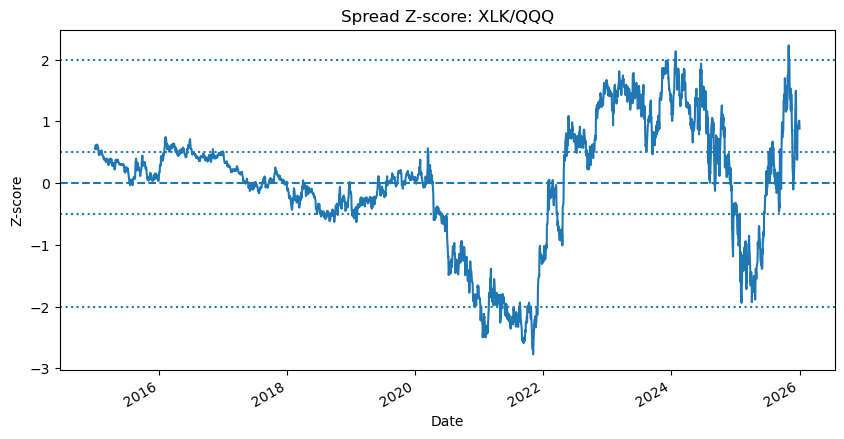

In [18]:
ax = zscore.plot(figsize=(10, 5))

ax.axhline(0, linestyle="--")
ax.axhline(2, linestyle=":")
ax.axhline(-2, linestyle=":")
ax.axhline(0.5, linestyle=":")
ax.axhline(-0.5, linestyle=":")

ax.set_title(f"Spread Z-score: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
plt.show()

In [19]:
print(zscore.describe())

count    2.766000e+03
mean    -5.137692e-17
std      1.000000e+00
min     -2.772886e+00
25%     -4.044649e-01
50%      9.007456e-02
75%      5.547155e-01
max      2.230479e+00
Name: XLK_QQQ_spread_zscore, dtype: float64


In [20]:
from src.signals import generate_spread_positions

positions = generate_spread_positions(
    zscore=zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

print(positions.head())
print(positions.value_counts())

Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64
XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64


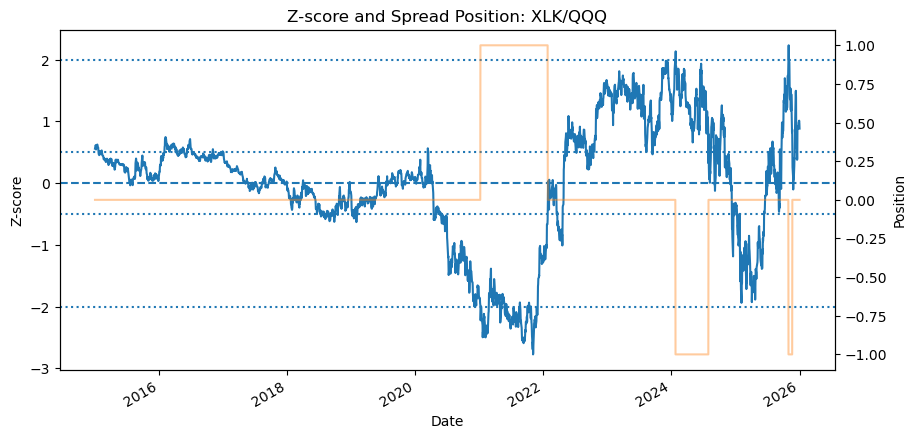

In [21]:
ax = zscore.plot(figsize=(10, 5))

ax.axhline(0, linestyle="--")
ax.axhline(2, linestyle=":")
ax.axhline(-2, linestyle=":")
ax.axhline(0.5, linestyle=":")
ax.axhline(-0.5, linestyle=":")

ax2 = positions.plot(secondary_y=True, alpha=0.4)

ax.set_title(f"Z-score and Spread Position: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
ax2.set_ylabel("Position")

plt.show()

In [22]:
print(positions.value_counts())
print(positions.head(20))
print(positions.tail(20))

XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64
Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
2015-01-09    0
2015-01-12    0
2015-01-13    0
2015-01-14    0
2015-01-15    0
2015-01-16    0
2015-01-20    0
2015-01-21    0
2015-01-22    0
2015-01-23    0
2015-01-26    0
2015-01-27    0
2015-01-28    0
2015-01-29    0
2015-01-30    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64
Date
2025-12-03    0
2025-12-04    0
2025-12-05    0
2025-12-08    0
2025-12-09    0
2025-12-10    0
2025-12-11    0
2025-12-12    0
2025-12-15    0
2025-12-16    0
2025-12-17    0
2025-12-18    0
2025-12-19    0
2025-12-22    0
2025-12-23    0
2025-12-24    0
2025-12-26    0
2025-12-29    0
2025-12-30    0
2025-12-31    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64


In [23]:
from src.backtest import compute_strategy_returns

strategy_returns = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
)

print(strategy_returns.head())
print(strategy_returns.describe())
print(strategy_returns.isna().sum())

Date
2015-01-05    0.0
2015-01-06    0.0
2015-01-07   -0.0
2015-01-08   -0.0
2015-01-09    0.0
Name: XLK_QQQ_strategy_returns, dtype: float64
count    2765.000000
mean        0.000020
std         0.000678
min        -0.005636
25%         0.000000
50%         0.000000
75%         0.000000
max         0.006537
Name: XLK_QQQ_strategy_returns, dtype: float64
0


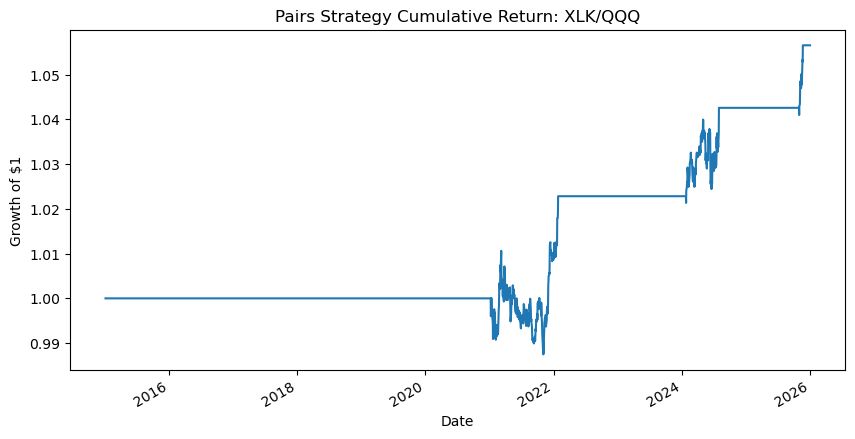

In [27]:
cumulative_strategy_returns = (1 + strategy_returns).cumprod()

ax = cumulative_strategy_returns.plot(figsize=(10, 5))

ax.set_title(f"Pairs Strategy Cumulative Return: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [28]:
print(strategy_returns.describe())
print(cumulative_strategy_returns.tail())

count    2765.000000
mean        0.000020
std         0.000678
min        -0.005636
25%         0.000000
50%         0.000000
75%         0.000000
max         0.006537
Name: XLK_QQQ_strategy_returns, dtype: float64
Date
2025-12-24    1.056531
2025-12-26    1.056531
2025-12-29    1.056531
2025-12-30    1.056531
2025-12-31    1.056531
Name: XLK_QQQ_strategy_returns, dtype: float64


In [32]:
from src.metrics import compute_cumulative_returns, compute_performance_metrics

cumulative_strategy_returns = compute_cumulative_returns(strategy_returns)
metrics = compute_performance_metrics(strategy_returns)

print(cumulative_strategy_returns.tail())
print(metrics)

Date
2025-12-24    1.056531
2025-12-26    1.056531
2025-12-29    1.056531
2025-12-30    1.056531
2025-12-31    1.056531
Name: XLK_QQQ_strategy_returns_cumulative_returns, dtype: float64
{'total_return': 0.056531321191390704, 'annualized_return': 0.005024436911625685, 'annualized_volatility': 0.01075650296547194, 'sharpe_ratio': 0.4713149865152298, 'max_drawdown': -0.02289761040244509}


In [33]:
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0565
annualized_return: 0.0050
annualized_volatility: 0.0108
sharpe_ratio: 0.4713
max_drawdown: -0.0229


In [34]:
print(positions.value_counts())

XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64


In [41]:
position_changes = positions.diff().fillna(0)

print(position_changes.value_counts())

XLK_QQQ_spread_zscore_position
 0.0    2760
 1.0       3
-1.0       3
Name: count, dtype: int64


In [44]:
n_position_changes = (positions.diff().fillna(0) != 0).sum()

days_in_market = (positions != 0).sum()
total_days = len(positions)

print("Number of position changes:", n_position_changes)
print("Days in market:", days_in_market)
print("Total days:", total_days)
print("Fraction in market:", days_in_market / total_days)

Number of position changes: 6
Days in market: 410
Total days: 2766
Fraction in market: 0.14822848879248013


In [48]:
strategy_returns_0bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=0.0,
)

strategy_returns_5bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=5.0,
)

strategy_returns_10bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=10.0,
)

In [52]:
for label, rets in {
    "0 bps": strategy_returns_0bps,
    "5 bps": strategy_returns_5bps,
    "10 bps": strategy_returns_10bps,
}.items():
    metrics = compute_performance_metrics(rets)

    print(label)
    for key, value in metrics.items():
        print(f"  {key}: {value:.4f}")
    print()

0 bps
  total_return: 0.0565
  annualized_return: 0.0050
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4713
  max_drawdown: -0.0229

5 bps
  total_return: 0.0534
  annualized_return: 0.0047
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4444
  max_drawdown: -0.0229

10 bps
  total_return: 0.0502
  annualized_return: 0.0045
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4172
  max_drawdown: -0.0229



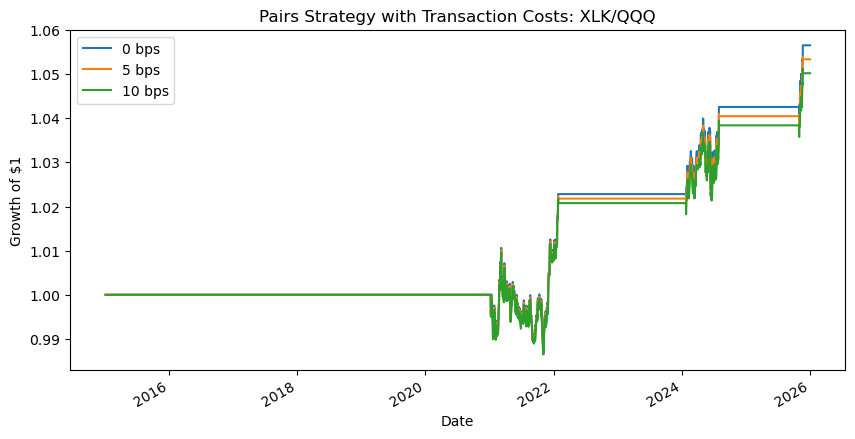

In [56]:
import pandas as pd

cum_0bps = compute_cumulative_returns(strategy_returns_0bps)
cum_5bps = compute_cumulative_returns(strategy_returns_5bps)
cum_10bps = compute_cumulative_returns(strategy_returns_10bps)

comparison = pd.concat(
    {
        "0 bps": cum_0bps,
        "5 bps": cum_5bps,
        "10 bps": cum_10bps,
    },
    axis=1,
)

ax = comparison.plot(figsize=(10, 5))

ax.set_title(f"Pairs Strategy with Transaction Costs: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [59]:
from src.trades import build_trade_log

trade_log = build_trade_log(
    positions=positions,
    strategy_returns=strategy_returns_5bps,
)

print(trade_log)

  entry_date exit_dadte     direction  holding_days  trade_return
0 2021-01-07 2022-01-26   long_spread           266      0.022306
1 2024-01-24 2024-07-30  short_spread           130      0.018795
2 2025-10-29 2025-11-20  short_spread            17      0.012889


In [61]:
print(trade_log["trade_return"].describe())
print("Number of trades:", len(trade_log))
print("Average holding days:", trade_log["holding_days"].mean())
print("Win rate:", (trade_log["trade_return"] > 0).mean())

count    3.000000
mean     0.017996
std      0.004759
min      0.012889
25%      0.015842
50%      0.018795
75%      0.020550
max      0.022306
Name: trade_return, dtype: float64
Number of trades: 3
Average holding days: 137.66666666666666
Win rate: 1.0
